# Validation on veer-only cases

### Literal equations with disk quantities from LES

\begin{equation}
U_{x} = \frac{U(1-a)}{U_{hub}} \cos(\Lambda - \zeta)
\end{equation}

\begin{equation}
U_{\tau} = (1 + a') \lambda r - \frac{U(1-a)}{U_{hub}} \sin( \Lambda - \zeta) \cos \psi
\end{equation}

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from wrf_io import postproc
from pathlib import Path
from MITRotor import IEA10MW
from matplotlib.ticker import FormatStrFormatter

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

In [5]:
fontsize = 20
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 
plt.rcParams['figure.dpi']      = 300

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [6]:
casenames = [
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200'
]

In [7]:
wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/'+casenames[count]+'_lite.npz')))

In [8]:
def rotor_average(f, r, theta):
    dr = np.gradient(r)
    dtheta = np.gradient(theta)

    area_elements = np.outer(dr * r, dtheta)
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)

    area_avg = np.sum(integrand) / A

    return area_avg

In [9]:
def annulus_average(f, theta):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(f * weights, axis=1)

    return X_azim

In [10]:
def annulus_to_rotor_average(f, r):

    dr = np.gradient(r)
    area_elements = 2 * np.pi * r * dr  # differential area for annular rings
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)  # total area of annulus from R1 to R2

    X_rotor =  np.sum(integrand) / A

    return X_rotor

In [11]:
def rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,w_rotor):

    precone = 0
    tilt    = 0
    trbYaw  = 0

    psi = 0.0
    angle = 2 * np.pi / Nsct

    Ux   = np.zeros_like(u_rotor,dtype='float')
    Utau = np.zeros_like(u_rotor,dtype='float')
    Ur   = np.zeros_like(u_rotor,dtype='float')

    for i in range(Nelm):
        for j in range(Nsct):
            transposePrecone = np.array([[np.cos(precone), 0, np.sin(precone)],[0,1,0],[-np.sin(precone), 0, np.cos(precone)]])
            transposeAzimuth = np.array([[1,0,0],[0,np.cos(psi),np.sin(psi)],[0,-np.sin(psi),np.cos(psi)]])
            transposeTilt    = np.array([[np.cos(tilt), 0, -np.sin(tilt)],[0,1,0],[np.sin(tilt), 0, np.cos(tilt)]])
            transposeYaw     = np.array([[np.cos(trbYaw), np.sin(trbYaw), 0],[-np.sin(trbYaw), np.cos(trbYaw), 0],[0,0,1]])

            psi = psi + angle

            PreconeAzimuth = np.matmul(transposePrecone, transposeAzimuth)
            PreconeAzimuthTilt = np.matmul(PreconeAzimuth, transposeTilt)
            PreconeAzimuthTiltYaw = np.matmul(PreconeAzimuthTilt, transposeYaw)

            local = np.matmul(PreconeAzimuthTiltYaw, np.array([[u_rotor[i,j]], [v_rotor[i,j]], [w_rotor[i,j]]]))

            Ux[i,j]   = local[0][0]
            Utau[i,j] = local[1][0]
            Ur[i,j]   = local[2][0]

    return Ux, Utau, Ur

In [20]:
Nelm = wrfles_bem[0]['Nelm']
Nsct = wrfles_bem[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles_bem[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['radius'] + z_hh

wrf_vax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_ONLINE = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_ONLINE = np.zeros(len(casenames),dtype='longdouble')

# shapiro      = np.zeros(len(casenames), dtype=float)

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles_bem[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    # u_rotor = np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0)
    u_rotor = np.mean(wrfles_bem[count]['u'],axis=0)
    v_rotor = np.mean(wrfles_bem[count]['v'],axis=0)
    # w_rotor = np.mean(wrfles_bem[count]['w'],axis=0)

    v_prime = v_rotor - v_inf.T

    # Magnitude of wind speed at rotor disk
    # U = np.sqrt(u_rotor**2 + v_rotor**2)
    U = np.sqrt(u_inf**2 + v_inf**2).T

    # Local wind misalignment angle at the rotor disk
    # wdir = np.atan2(v_rotor,u_rotor)
    wdir = np.atan2(v_inf,u_inf).T

    # Nondimensional radial positions
    r = wrfles_bem[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles_bem[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    a = 1 - u_rotor / U_hub
    a_prime = 0

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles_bem[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles_bem[count]['yaw'], axis=0) 

    u_fst = (U / U_hub * (1 - a) * np.cos(wdir))
    v_fst = (U / U_hub * (1 - a) * np.sin(wdir))

    # Vax, Vtn_NR, _ = rotGlobalToLocal(Nelm,Nsct,u_fst,v_fst,np.zeros_like(u_rotor))
    Vax, Vtn_NR, _ = rotGlobalToLocal(Nelm,Nsct,u_fst,v_fst,np.zeros_like(u_rotor))

    Vtn = (1 + a_prime) * tsr * r_mat - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    L = 1/2 * rho * chord * (Cl * (W * U_hub)**2)
    D = 1/2 * rho * chord * (Cd * (W * U_hub)**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)


# ----------------- NEW OFFLINE LES REFERENCE -----------------

    # Vax_LES = (
    #     u_rotor  * np.cos(trbYaw) + 
    #     v_rotor  * np.sin(trbYaw)
    # )
    
    # Vtn_LES = (
    #    omega * r_mat * R - (
    #     - np.cos(theta) * np.sin(trbYaw) * u_rotor + 
    #       np.cos(theta) * np.cos(trbYaw) * v_rotor
    #    )
    # )

    Vax_LES, Vtn_LES_NR, _ = rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor - v_prime,np.zeros_like(u_rotor))

    Vtn_LES = omega * r_mat * R -Vtn_LES_NR

    # Relative velocity
    W_LES = np.sqrt(Vax_LES**2 + Vtn_LES**2)

    # Inflow angle
    phi_LES = np.atan2(Vax_LES,Vtn_LES)

    aoa_LES  = phi_LES - twist[:, np.newaxis]
    Cl_LES, Cd_LES = rotor.clcd(r_mat, aoa_LES)

    L_LES = 1/2 * rho * chord * (Cl_LES * W_LES**2)
    D_LES = 1/2 * rho * chord * (Cd_LES * W_LES**2)

    FN_LES = L_LES * np.cos(phi_LES) + D_LES * np.sin(phi_LES)
    FT_LES = L_LES * np.sin(phi_LES) - D_LES * np.cos(phi_LES)

    dr = (R - rotor.hub_radius)/Nelm

    T_LES = np.sum(FN_LES * dr * sigma)
    P_LES = np.sum(FT_LES * r_mat * R * dr * sigma * omega)

# -------------------------------------------------------------

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtn

    wrf_vax_real[:,:,count] = Vax_LES / U_hub
    wrf_vtn_real[:,:,count] = Vtn_LES / U_hub

    wrf_phi[:,:,count]      = phi
    wrf_phi_real[:,:,count] = phi_LES

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = aoa_LES

    wrf_W[:,:,count]        = W
    wrf_W_real[:,:,count]   = W_LES

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = Cl_LES
    wrf_CD_real[:,:,count]  = Cd_LES

    wrf_L[:,:,count]        = L
    wrf_D[:,:,count]        = D

    wrf_L_real[:,:,count]   = L_LES
    wrf_D_real[:,:,count]   = D_LES

    wrf_FN[:,:,count]       = FN
    wrf_FT[:,:,count]       = FT

    wrf_FN_real[:,:,count]  = FN_LES
    wrf_FT_real[:,:,count]  = FT_LES

    wrf_thr[count]          = T
    wrf_pow[count]          = P

    wrf_thr_real[count]     = T_LES
    wrf_pow_real[count]     = P_LES

    wrf_thr_ONLINE[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)[0]
    wrf_pow_ONLINE[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)[0]

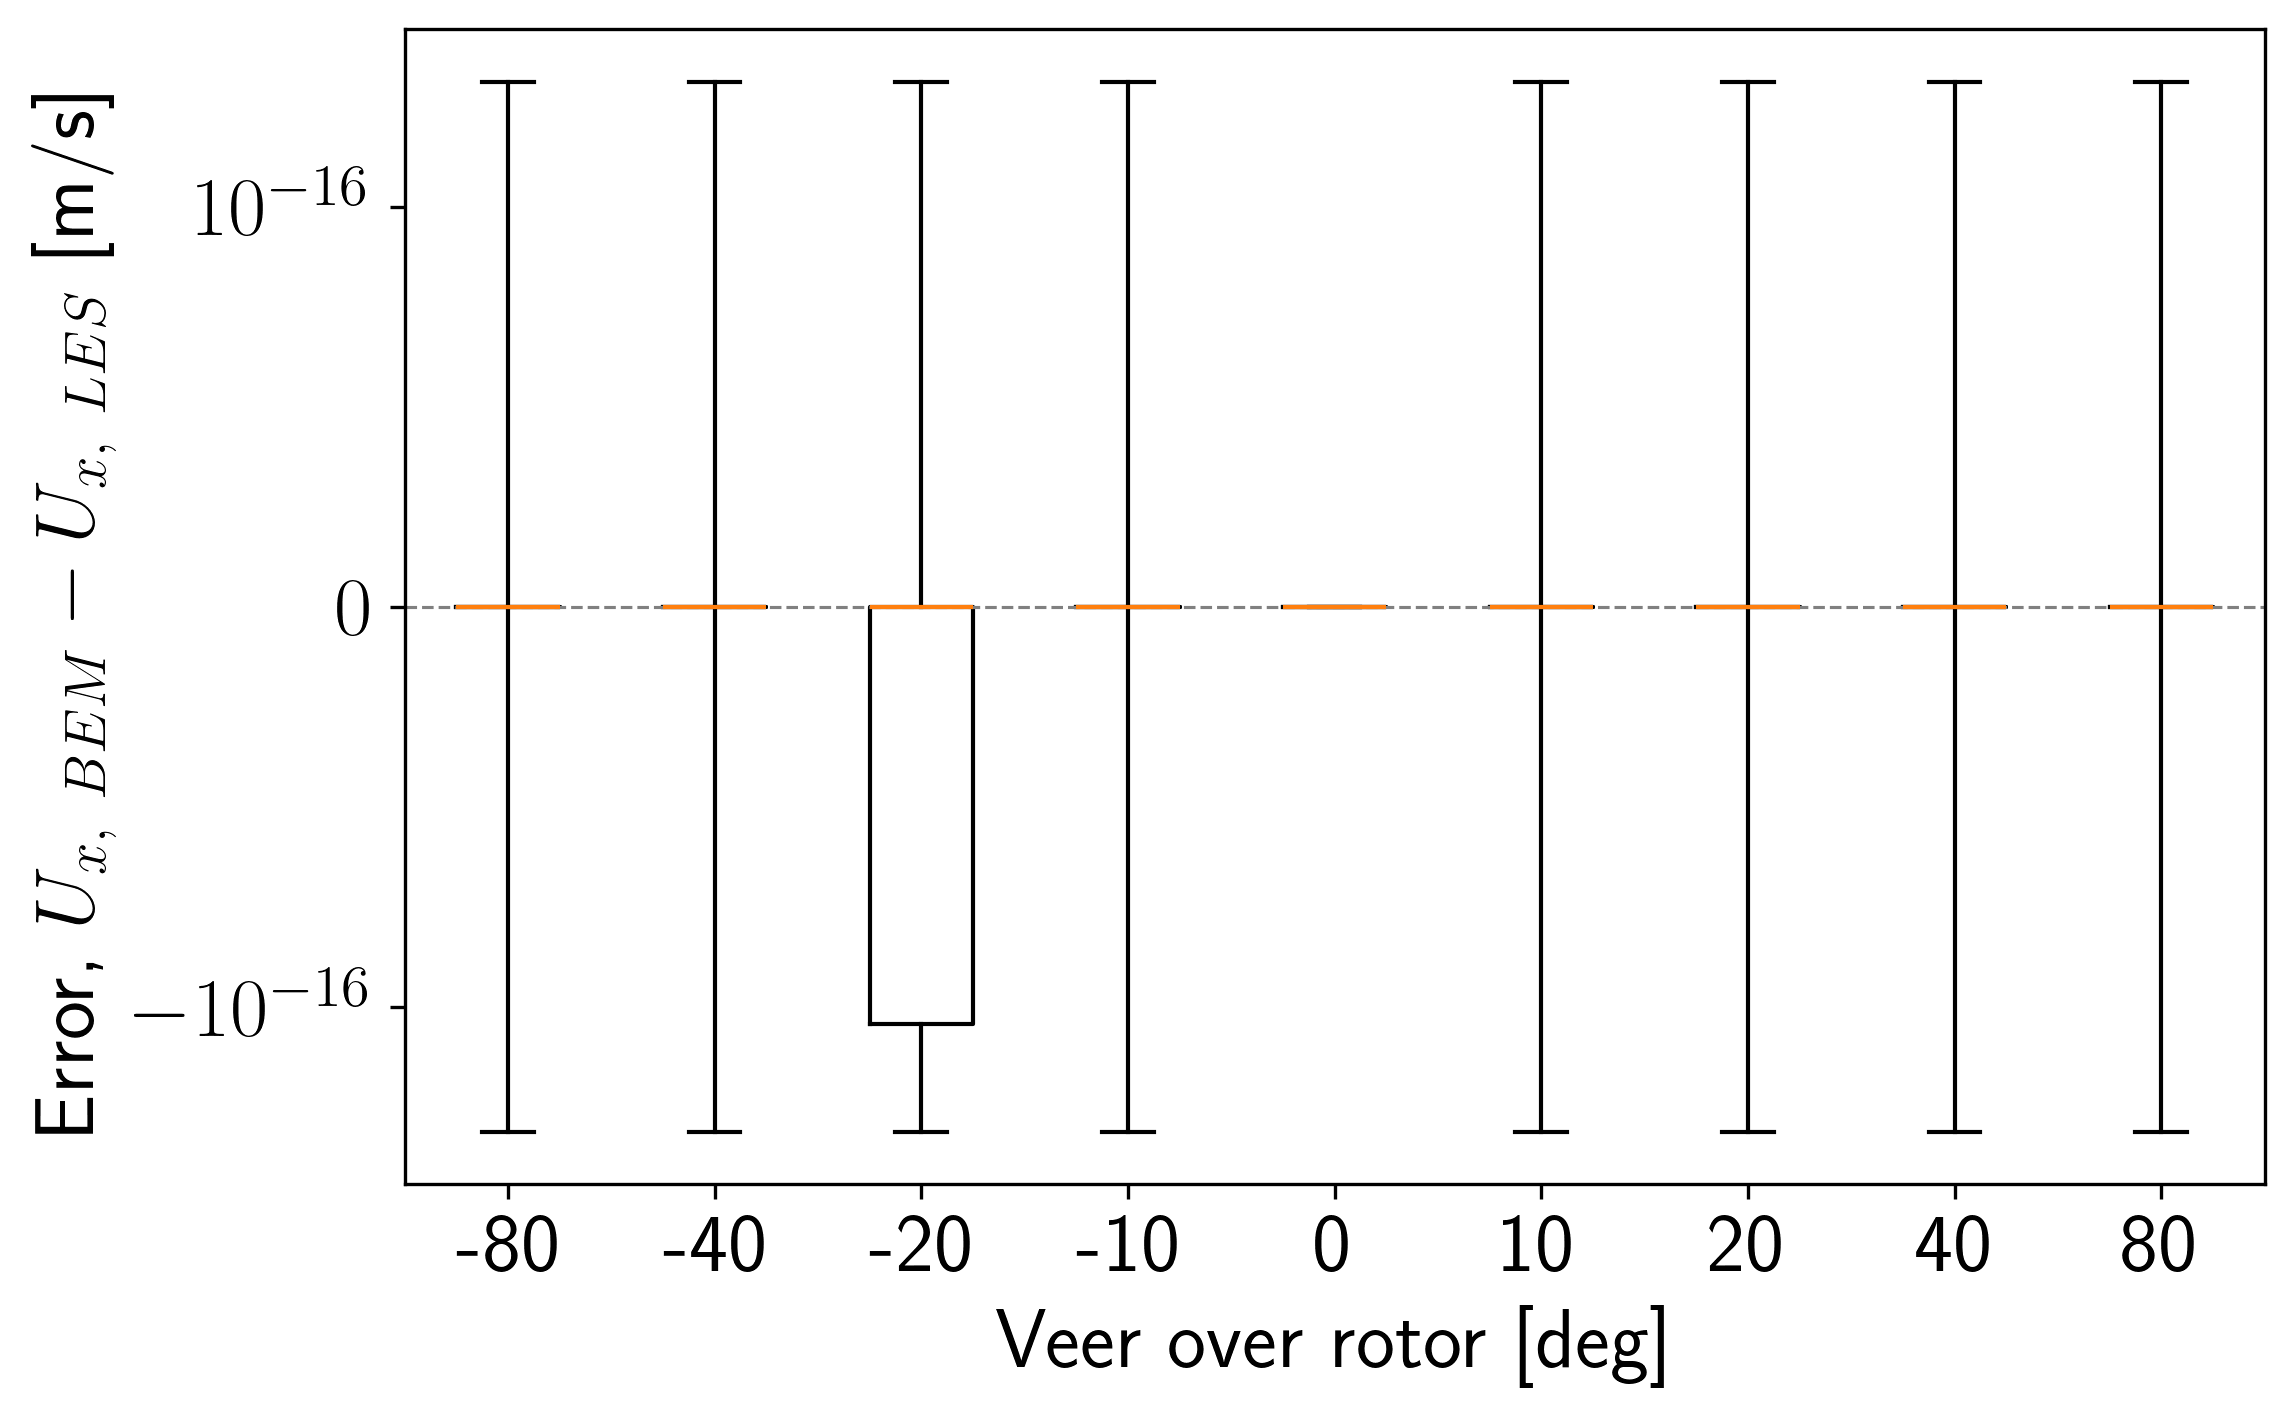

In [21]:
# Axial velocity component

Q1 = np.zeros(len(casenames),dtype='float')
Q2 = np.zeros(len(casenames),dtype='float')
Q3 = np.zeros(len(casenames),dtype='float')
Q4 = np.zeros(len(casenames),dtype='float')
Q5 = np.zeros(len(casenames),dtype='float')

for i in range(len(casenames)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(wrf_vax[:,:,i] - wrf_vax_real[:,:,i], [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Error, $U_{x, \ BEM} - U_{x, \ LES}$ [m/s]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog',linthresh=1e-16)

# ax.set_ylim([-1e-16,1e-16])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

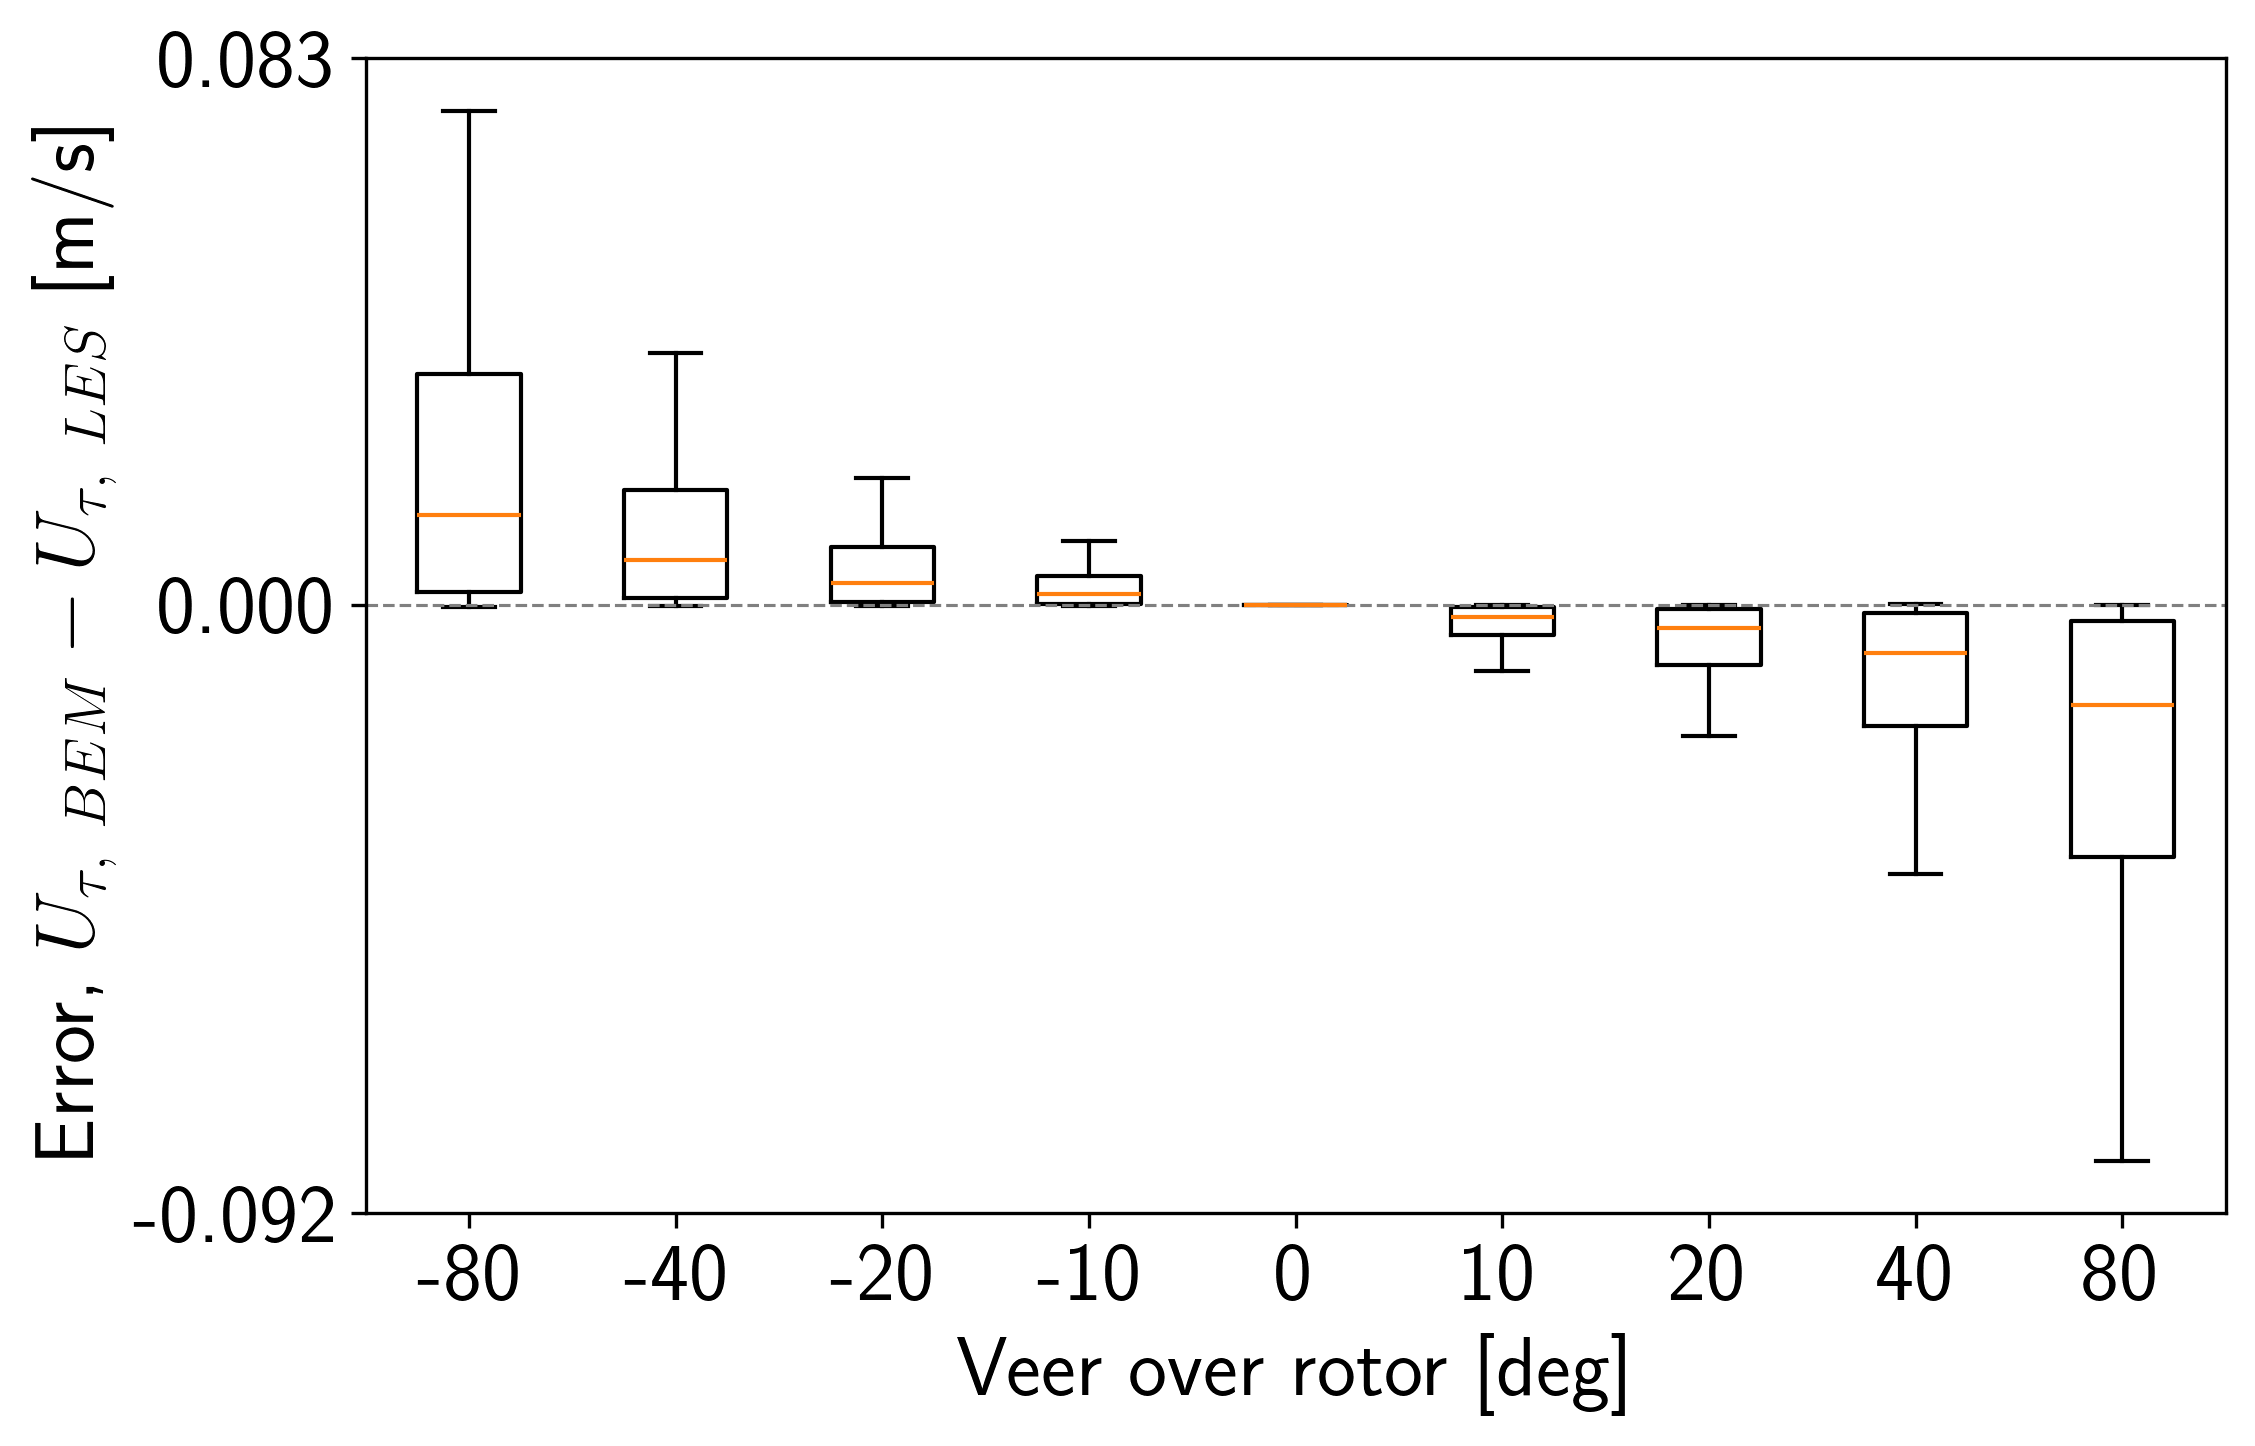

In [22]:
# Tangential velocity component (with rotation)

Q1 = np.zeros(len(casenames),dtype='float')
Q2 = np.zeros(len(casenames),dtype='float')
Q3 = np.zeros(len(casenames),dtype='float')
Q4 = np.zeros(len(casenames),dtype='float')
Q5 = np.zeros(len(casenames),dtype='float')

for i in range(len(casenames)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(wrf_vtn[:,:,i] - wrf_vtn_real[:,:,i], [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Error, $U_{\\tau, \ BEM} - U_{\\tau, \ LES}$ [m/s]",fontsize=fontsize)
# ax.set_title("Tangential velocity component, $V_{tan}$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
# ax.set_ylim([-10,10])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

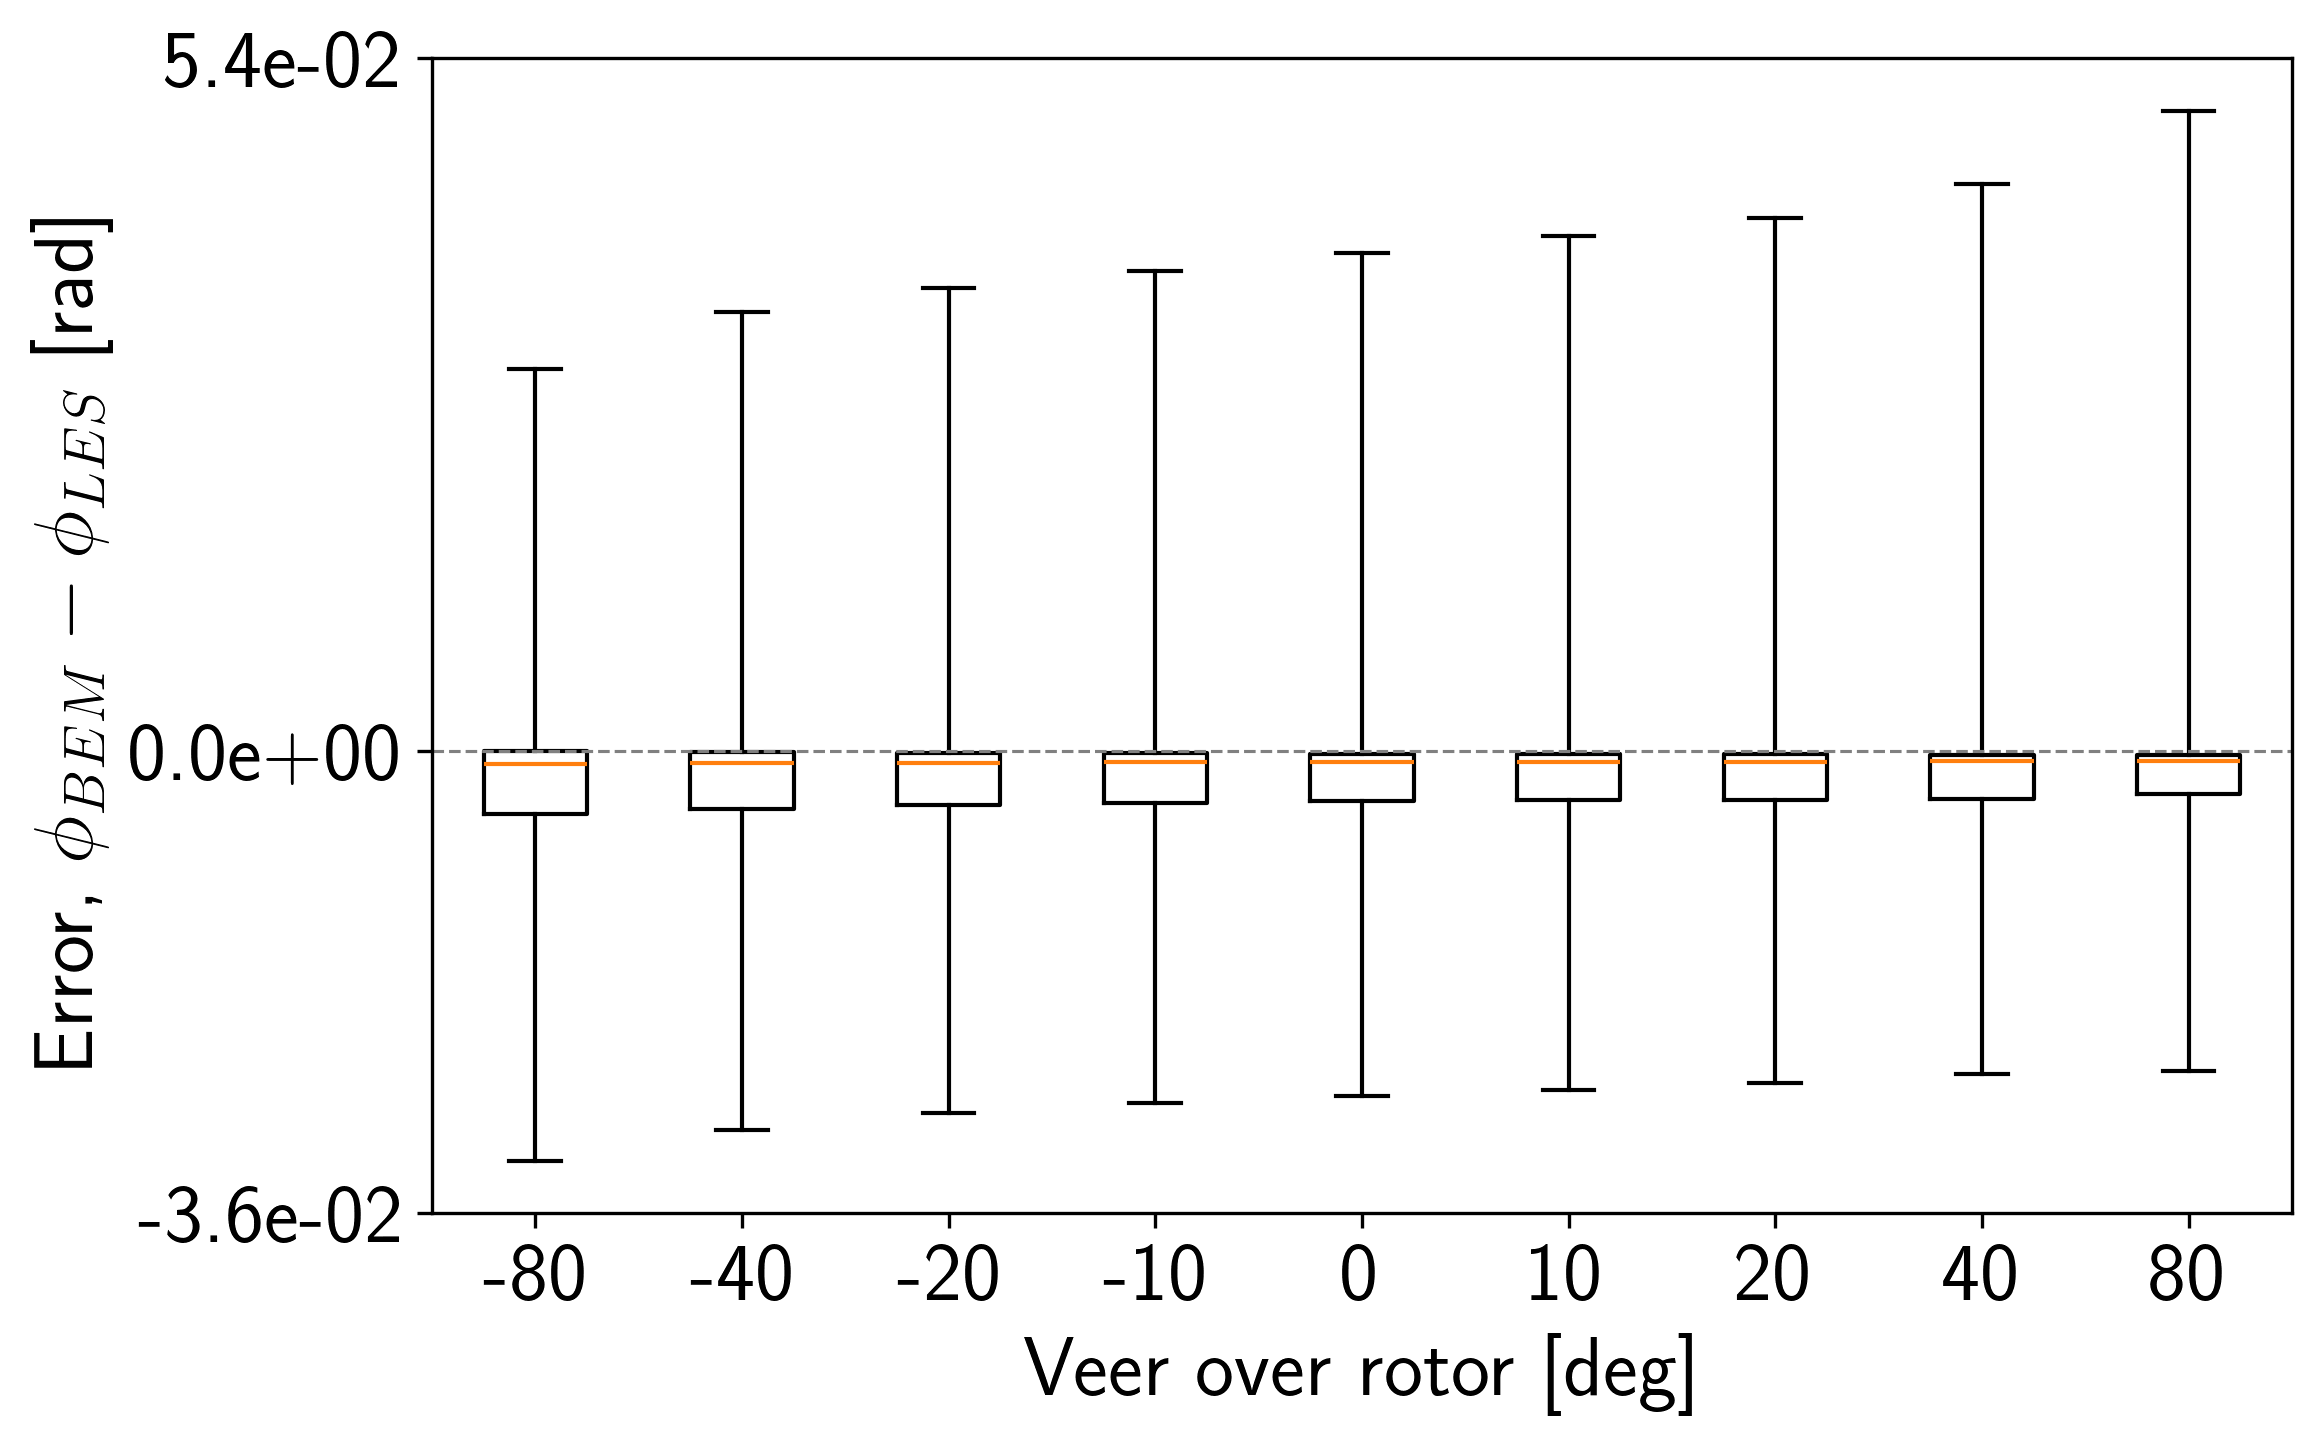

In [58]:
# Inflow angle

Q1 = np.zeros(len(casenames),dtype='float')
Q2 = np.zeros(len(casenames),dtype='float')
Q3 = np.zeros(len(casenames),dtype='float')
Q4 = np.zeros(len(casenames),dtype='float')
Q5 = np.zeros(len(casenames),dtype='float')

for i in range(len(casenames)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(wrf_phi[:,:,i] - wrf_phi_real[:,:,i], [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Error, $\phi_{BEM} - \phi_{LES}$ [rad]",fontsize=fontsize)
# ax.set_title("Inflow angle, $\phi$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
# ax.set_ylim([-10,10])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

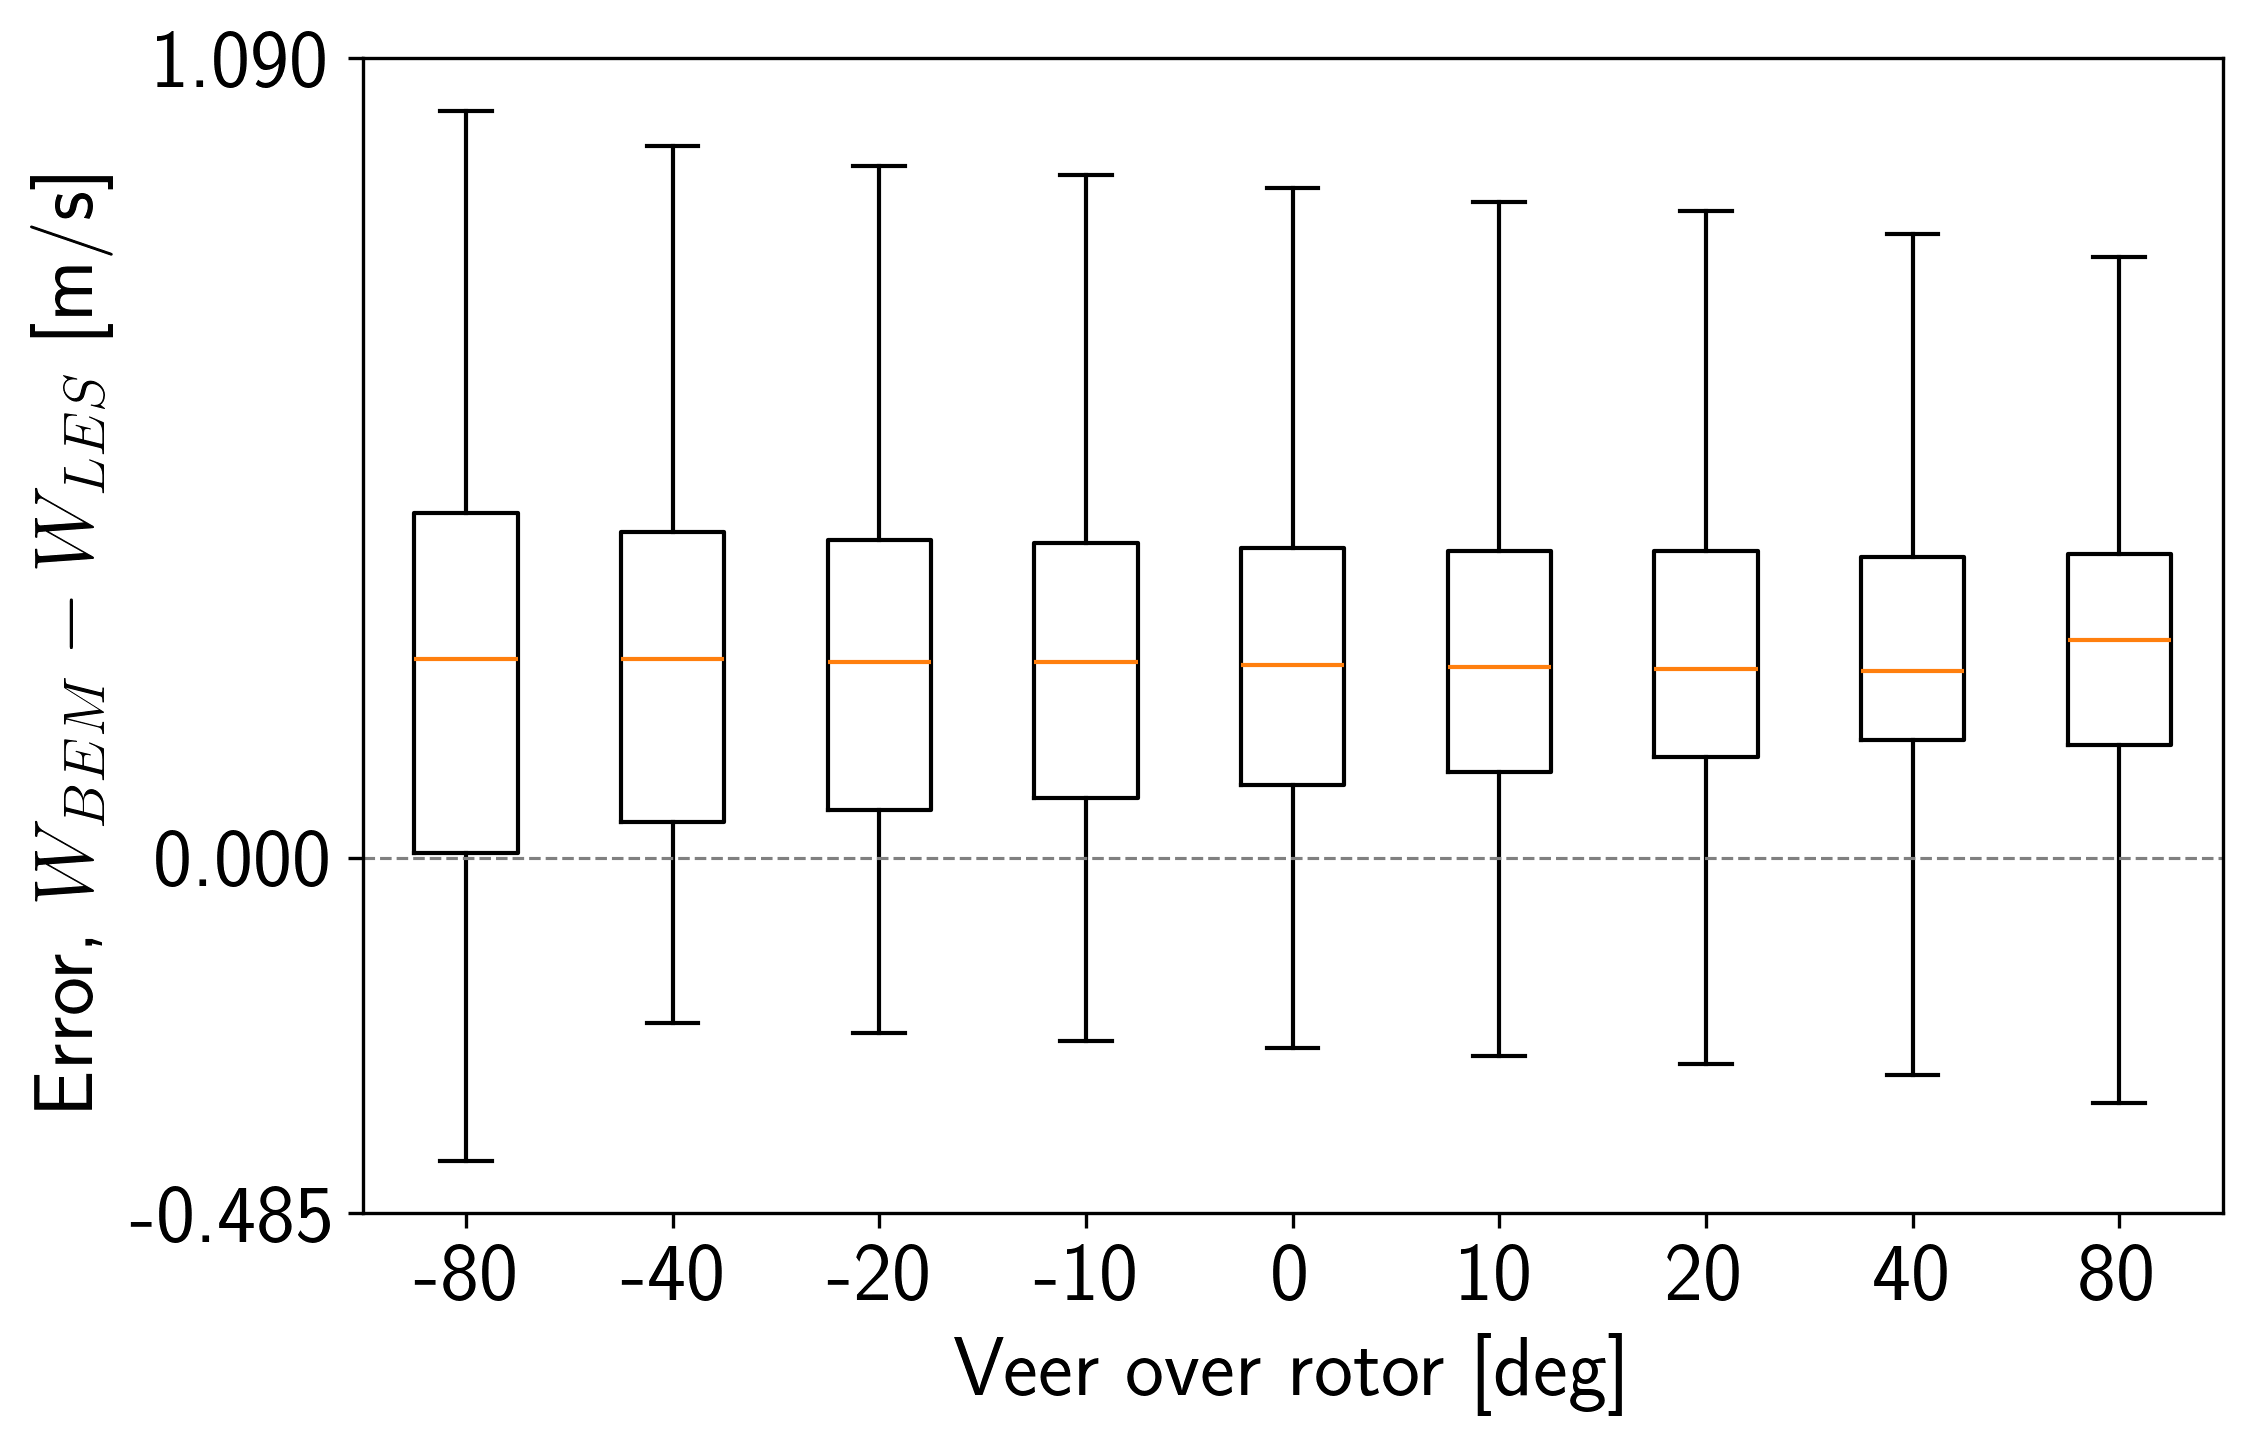

In [45]:
# Relative velocity

Q1 = np.zeros(len(casenames),dtype='float')
Q2 = np.zeros(len(casenames),dtype='float')
Q3 = np.zeros(len(casenames),dtype='float')
Q4 = np.zeros(len(casenames),dtype='float')
Q5 = np.zeros(len(casenames),dtype='float')

for i in range(len(casenames)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(wrf_W[:,:,i] - wrf_W_real[:,:,i], [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Error, $W_{BEM} - W_{LES}$ [m/s]",fontsize=fontsize)
# ax.set_title("Relative velocity, $W$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
# ax.set_ylim([-10,10])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

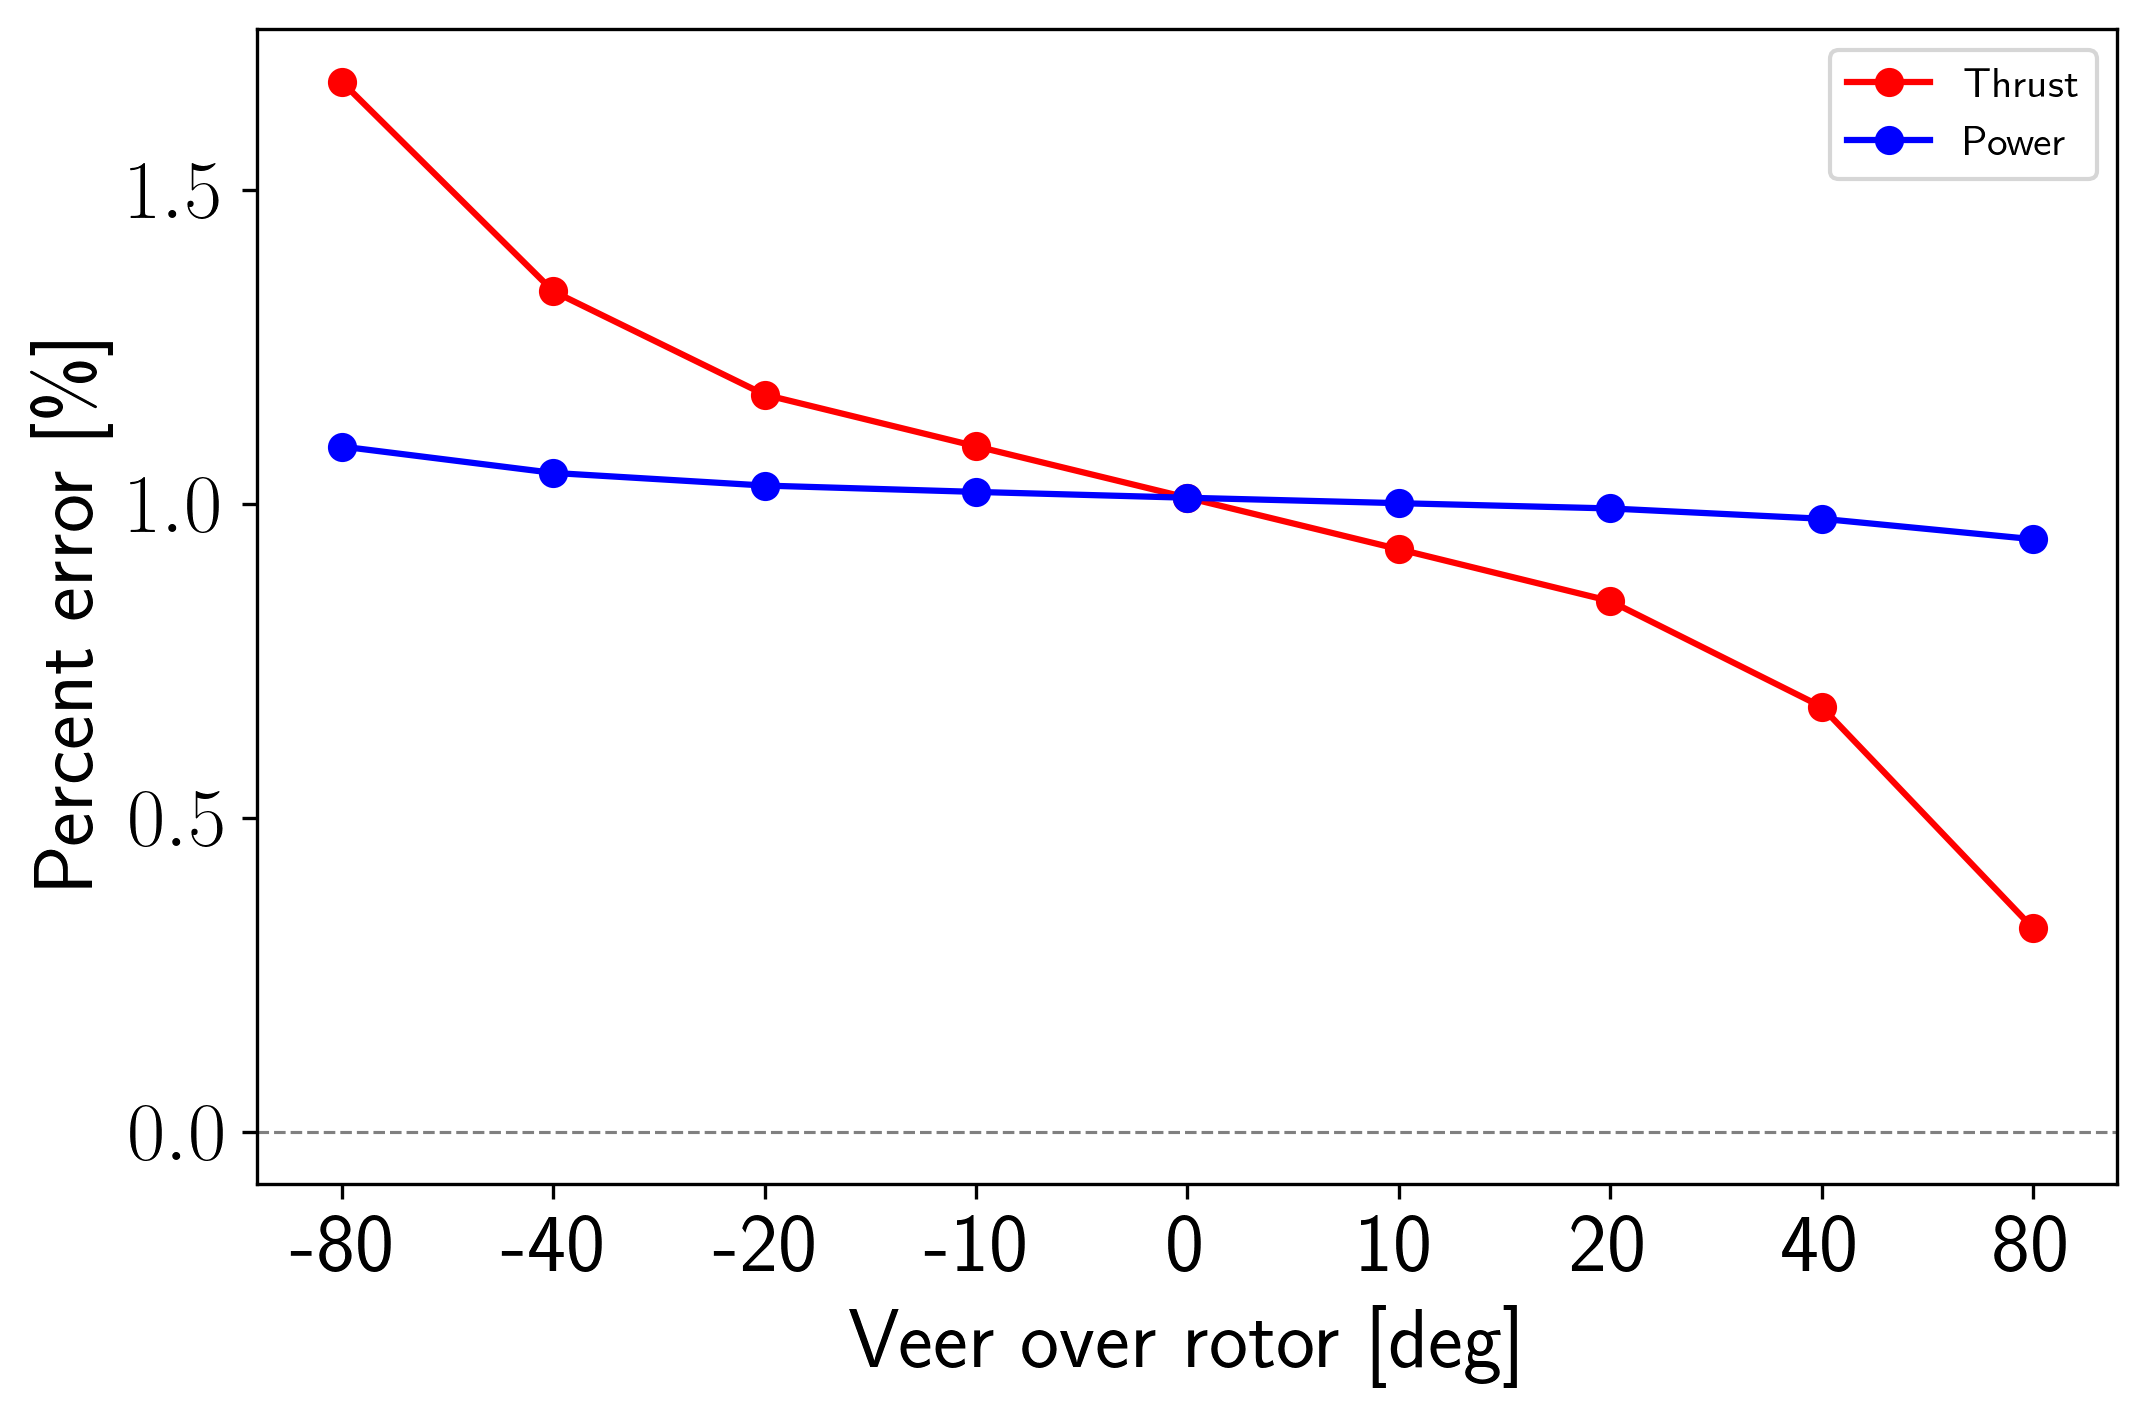

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

thr_err = postproc.per_error(wrf_thr, wrf_thr_real)
pow_err = postproc.per_error(wrf_pow, wrf_pow_real)

ax.plot(thr_err, color='r', label='Thrust', marker='o')
ax.plot(pow_err, color='b', label='Power', marker='o')


ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(casenames)-1,len(casenames)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
# ax.set_ylim([-1e-1,1])

# ax.set_yscale('symlog',linthresh=1e-2)
# ax.set_ylim([-8e-2,1e-2])

ax.legend()

plt.show()

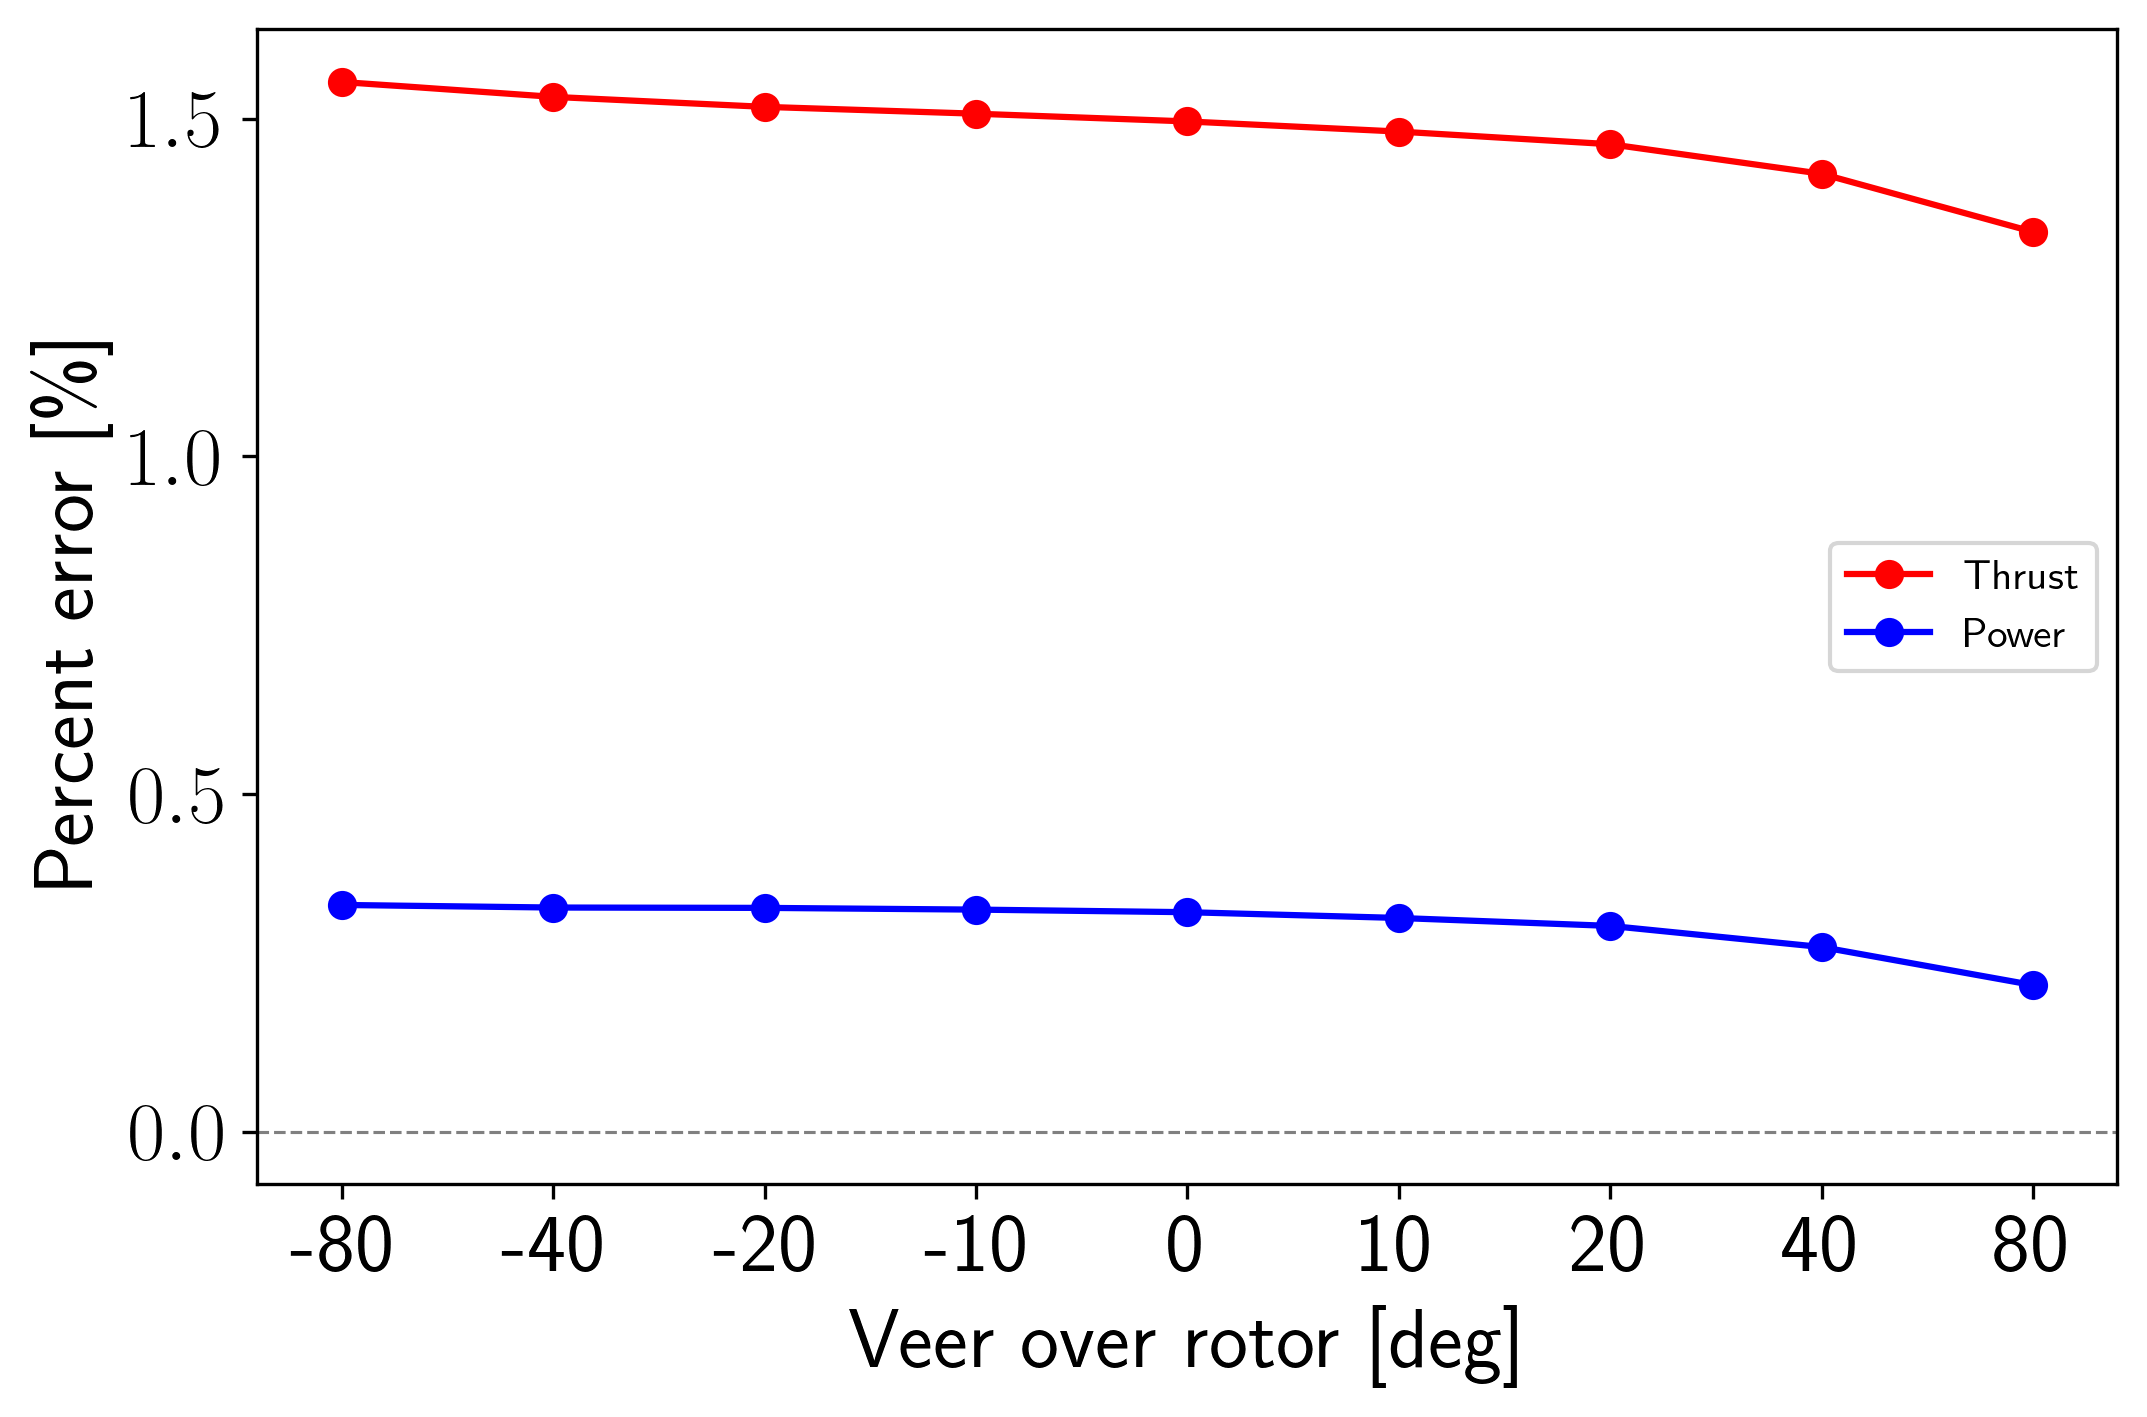

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))

thr_err = postproc.per_error(wrf_thr, wrf_thr_ONLINE)
pow_err = postproc.per_error(wrf_pow, wrf_pow_ONLINE)

ax.plot(thr_err, color='r', label='Thrust', marker='o')
ax.plot(pow_err, color='b', label='Power', marker='o')


ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(casenames)-1,len(casenames)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
# ax.set_ylim([-1e-1,1])

# ax.set_yscale('symlog',linthresh=1e-2)
# ax.set_ylim([-8e-2,1e-2])

ax.legend()

plt.show()

In [68]:
err_T_no_w = np.array([0.6223235 , 0.66911177, 0.69503755, 0.70803688, 0.72073521,0.73339877, 0.74434632, 0.76014689, 0.77040243])
err_P_no_w = np.array([0.15198042, 0.15603118, 0.15954827, 0.16102327, 0.16270435,0.16402812, 0.16378308, 0.1568445 , 0.12581516])

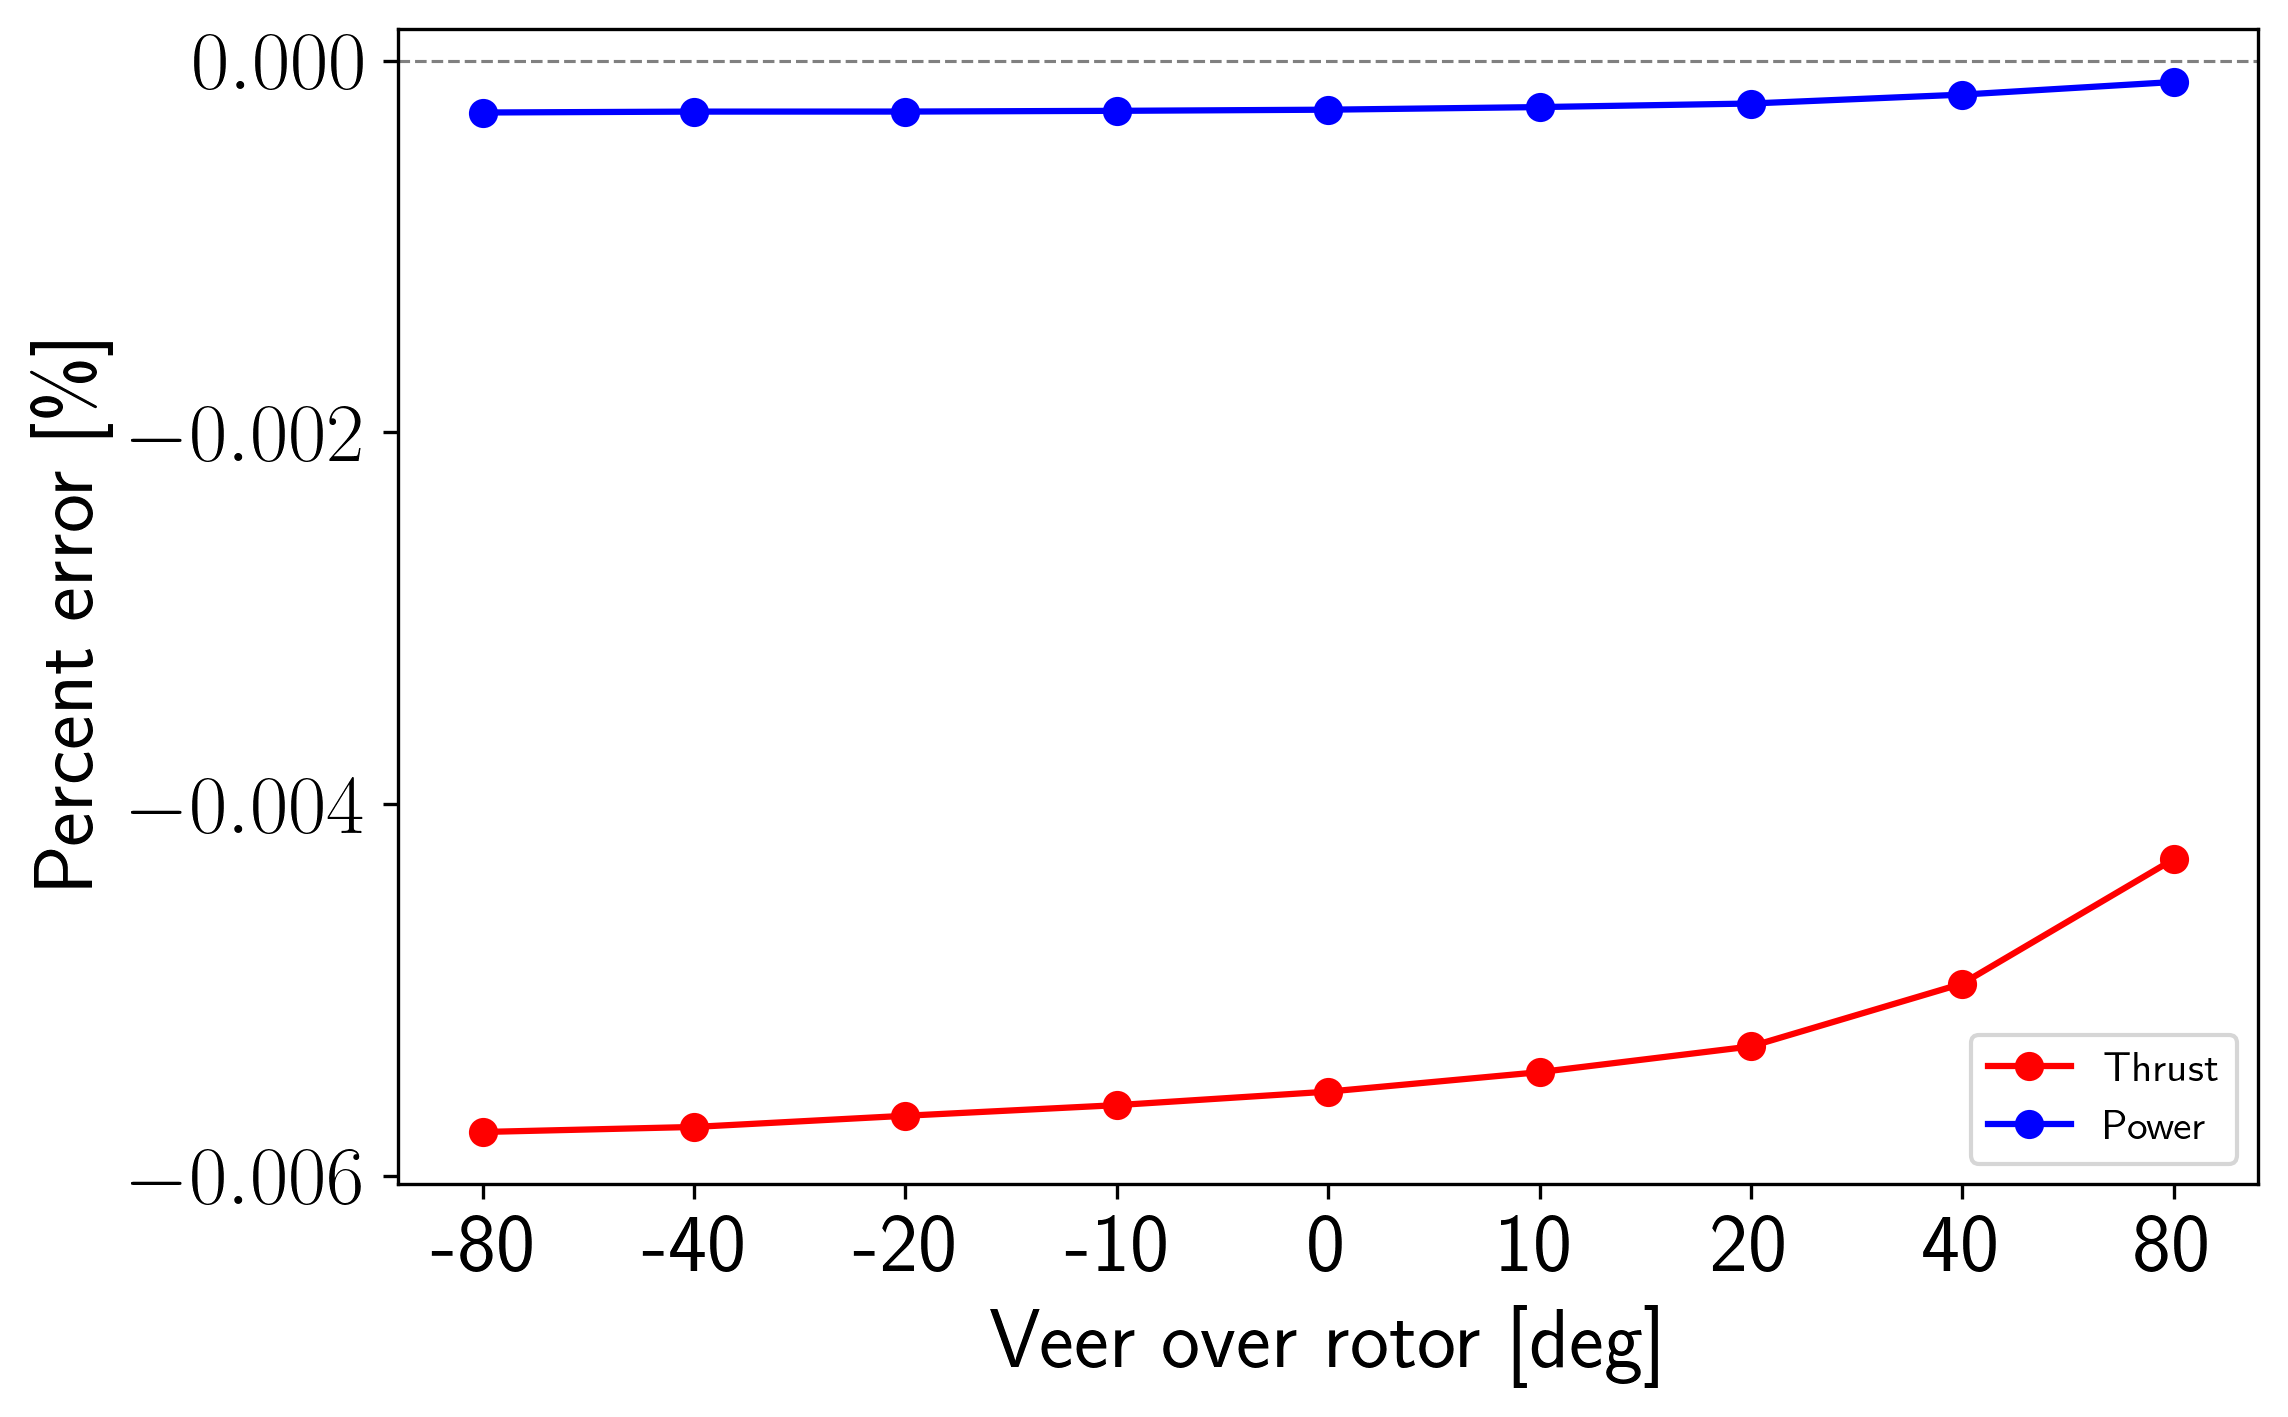

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

thr_err = postproc.per_error(wrf_thr, wrf_thr_real) - (postproc.per_error(wrf_thr, wrf_thr_ONLINE) - err_T_no_w)
pow_err = postproc.per_error(wrf_pow, wrf_pow_real) - (postproc.per_error(wrf_pow, wrf_pow_ONLINE) - err_P_no_w)

ax.plot(thr_err, color='r', label='Thrust', marker='o')
ax.plot(pow_err, color='b', label='Power', marker='o')


ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(casenames)-1,len(casenames)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
# ax.set_ylim([-1e-1,1])

# ax.set_yscale('symlog',linthresh=1e-2)
# ax.set_ylim([-8e-2,1e-2])

ax.legend()

plt.show()

In [37]:
wrf_thr/1e3

array([630.7055487 , 638.02431369, 640.74731316, 641.77443617,
       642.55102539, 643.03428782, 643.23455341, 642.84174995,
       639.50195531], dtype=float128)

In [38]:
wrf_thr_real/1e3

array([625.06168945, 632.75149963, 635.71182935, 636.87863157,
       637.8038041 , 638.46060793, 638.84912166, 638.84113299,
       636.13995059], dtype=float128)

In [75]:
wrf_pow/1e6

array([2.9176112 , 2.94200094, 2.94374996, 2.94104272, 2.93566092,
       2.92722656, 2.91587643, 2.88529275, 2.80094749], dtype=float128)

In [76]:
wrf_pow_real/1e6

array([2.9122591 , 2.93683449, 2.93869867, 2.93611398, 2.93090246,
       2.92276906, 2.91176994, 2.88192857, 2.79838612], dtype=float128)